In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

sns.set_style("whitegrid")

In [2]:
data_path = "/content/communities.data"

df = pd.read_csv(
    data_path,
    header=None,
    na_values="?",
    skipinitialspace=True
)


In [3]:
df.columns = [f"Feature_{i}" for i in range(df.shape[1])]

In [4]:
print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
display(df.describe(include="all").T)

Shape: (1994, 128)

First 5 rows:


,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_118,Feature_119,Feature_120,Feature_121,Feature_122,Feature_123,Feature_124,Feature_125,Feature_126,Feature_127
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,34,5.0,81440.0,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,42,95.0,6096.0,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 128 entries, Feature_0 to Feature_127
dtypes: float64(125), int64(2), object(1)
memory usage: 1.9+ MB

Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Feature_0,1994.0,NaN,NaN,NaN,28.683551,16.397553,1.0,12.0,34.0,42.0,56.0
Feature_1,820.0,NaN,NaN,NaN,58.826829,126.42056,1.0,9.0,23.0,59.5,840.0
Feature_2,817.0,NaN,NaN,NaN,46188.336597,25299.726569,70.0,25065.0,48090.0,66660.0,94597.0
Feature_3,1994,1828,Jacksonvillecity,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Feature_4,1994.0,NaN,NaN,NaN,5.493982,2.873694,1.0,3.0,5.0,8.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...
Feature_123,319.0,NaN,NaN,NaN,0.698589,0.213944,0.0,0.62,0.75,0.84,1.0
Feature_124,319.0,NaN,NaN,NaN,0.440439,0.405808,0.0,0.0,0.5,1.0,1.0
Feature_125,1994.0,NaN,NaN,NaN,0.094052,0.240328,0.0,0.0,0.0,0.0,1.0
Feature_126,319.0,NaN,NaN,NaN,0.195078,0.164718,0.0,0.11,0.15,0.22,1.0


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1994
Number of columns: 128


In [6]:
print("\nData types:")
print(df.dtypes.value_counts())


Data types:
float64    125
int64        2
object       1
Name: count, dtype: int64


In [7]:
print("\nMissing values in each column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0].sort_values(ascending=False))

print("\nTotal missing values:", df.isnull().sum().sum())


Missing values in each column:
Feature_102    1675
Feature_105    1675
Feature_101    1675
Feature_104    1675
Feature_103    1675
Feature_106    1675
Feature_109    1675
Feature_108    1675
Feature_107    1675
Feature_115    1675
Feature_116    1675
Feature_117    1675
Feature_110    1675
Feature_111    1675
Feature_112    1675
Feature_113    1675
Feature_114    1675
Feature_122    1675
Feature_123    1675
Feature_124    1675
Feature_121    1675
Feature_126    1675
Feature_2      1177
Feature_1      1174
Feature_30        1
dtype: int64

Total missing values: 39202


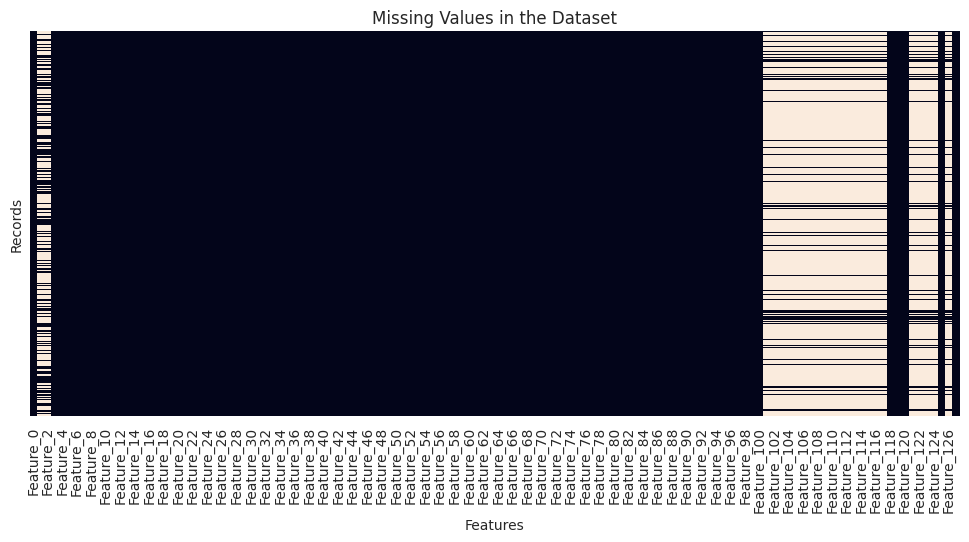

In [8]:
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values in the Dataset")
plt.xlabel("Features")
plt.ylabel("Records")
plt.show()

In [9]:
# Remove the first five identifier/metadata columns
X = df.iloc[:, 5:].copy()

# Convert all remaining columns to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Remove columns that contain no valid numerical values
X = X.dropna(axis=1, how="all")

# Remove columns with no variation
X = X.loc[:, X.nunique(dropna=True) > 1]

print("Shape before preprocessing:", X.shape)
print("Total missing values:", X.isnull().sum().sum())

# Replace missing values with each column's median
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

print("\nShape after imputation:", X_imputed.shape)
print("Missing values after imputation:", np.isnan(X_imputed).sum())

Shape before preprocessing: (1994, 123)
Total missing values: 36851

Shape after imputation: (1994, 123)
Missing values after imputation: 0


In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

print("Standardized data shape:", X_scaled.shape)
print("\nMean of first 5 standardized features:")
print(np.round(X_scaled.mean(axis=0)[:5], 4))

print("\nStandard deviation of first 5 standardized features:")
print(np.round(X_scaled.std(axis=0)[:5], 4))

Standardized data shape: (1994, 123)

Mean of first 5 standardized features:
[ 0. -0.  0.  0.  0.]

Standard deviation of first 5 standardized features:
[1. 1. 1. 1. 1.]


In [11]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Find the components needed to explain 95% of the variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Original number of features:", X_scaled.shape[1])
print("Total PCA components:", pca_full.n_components_)
print("Components required for 95% variance:", n_components_95)
print(
    "Variance explained by selected components:",
    round(cumulative_variance[n_components_95 - 1] * 100, 2), "%"
)

Original number of features: 123
Total PCA components: 123
Components required for 95% variance: 45
Variance explained by selected components: 95.22 %


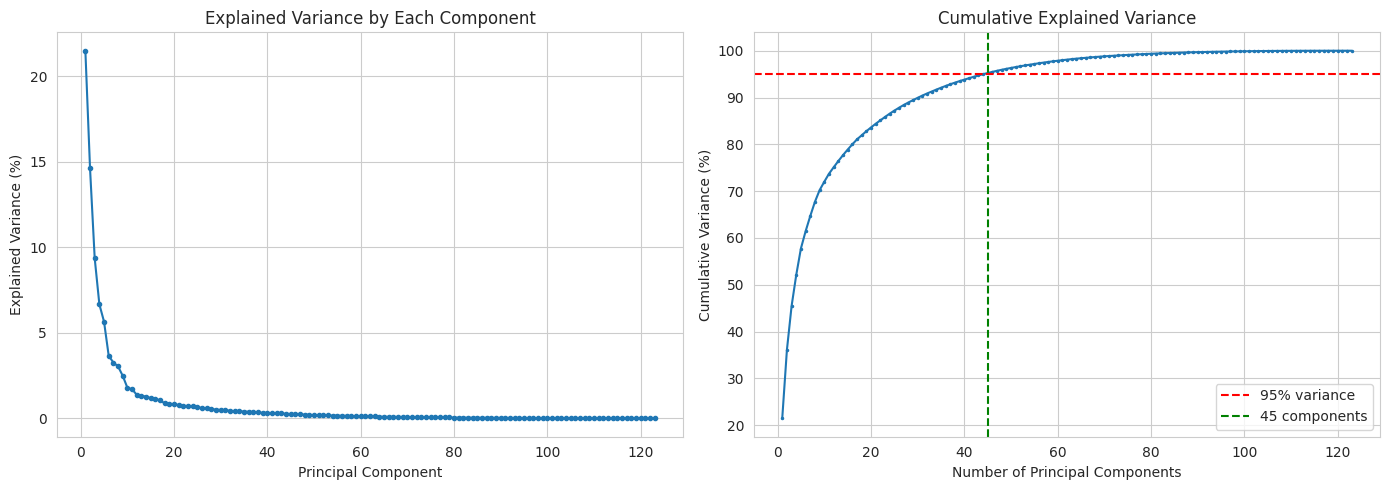

In [12]:
components = np.arange(1, len(explained_variance) + 1)

plt.figure(figsize=(14, 5))

# Individual explained variance
plt.subplot(1, 2, 1)
plt.plot(components, explained_variance * 100, marker="o", markersize=3)
plt.title("Explained Variance by Each Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.grid(True)

# Cumulative explained variance
plt.subplot(1, 2, 2)
plt.plot(components, cumulative_variance * 100, marker=".", markersize=3)
plt.axhline(y=95, color="red", linestyle="--", label="95% variance")
plt.axvline(
    x=n_components_95,
    color="green",
    linestyle="--",
    label=f"{n_components_95} components"
)
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
# Reduce dimensions while retaining at least 95% variance
pca = PCA(n_components=n_components_95)

X_reduced = pca.fit_transform(X_scaled)

# Store the reduced data in a DataFrame
pca_columns = [
    f"PC{i+1}" for i in range(n_components_95)
]

df_pca = pd.DataFrame(
    X_reduced,
    columns=pca_columns,
    index=X.index
)

print("Reduced dataset shape:", df_pca.shape)

print("\nFirst 5 rows of reduced data:")
display(df_pca.head())

print(
    "\nTotal variance retained:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

Reduced dataset shape: (1994, 45)

First 5 rows of reduced data:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC36,PC37,PC38,PC39,PC40,PC41,PC42,PC43,PC44,PC45
0,1.702796,-0.738582,2.166079,-2.406092,-0.825983,-4.121150,0.780554,0.161350,0.317840,0.429595,...,0.940252,0.756901,0.141149,0.288909,-0.545527,-0.342790,-0.008626,0.091693,0.361036,0.036427
1,-1.564543,0.257813,1.122003,-5.069605,2.039323,-3.669566,2.527208,1.514403,2.110313,-0.105290,...,-0.226805,-0.154264,0.288038,0.272711,-0.424264,0.245303,1.659067,0.435817,-0.016461,0.143229
2,-1.825207,-2.743532,-0.061517,0.231123,0.471427,-1.385532,1.917326,1.997966,-0.122818,-0.167487,...,0.781010,-0.298090,0.540069,0.121574,0.105022,-0.076665,0.804314,-1.022376,-0.526611,-0.281409
3,2.923541,2.024646,-2.066051,3.027910,-2.380926,1.166463,1.654890,4.674199,-0.366974,0.926360,...,1.213835,-2.162932,0.079252,-0.082749,-0.679311,0.723173,0.028765,-0.332594,0.317183,-0.791553
4,5.904712,-1.902934,-0.118541,2.862099,-2.021257,-0.186667,0.626082,-0.489904,0.246059,-0.715096,...,-0.220270,-0.202287,-0.142443,-0.683676,0.928452,0.061620,-0.500996,-0.654575,0.683449,-0.000087



Total variance retained: 95.22 %


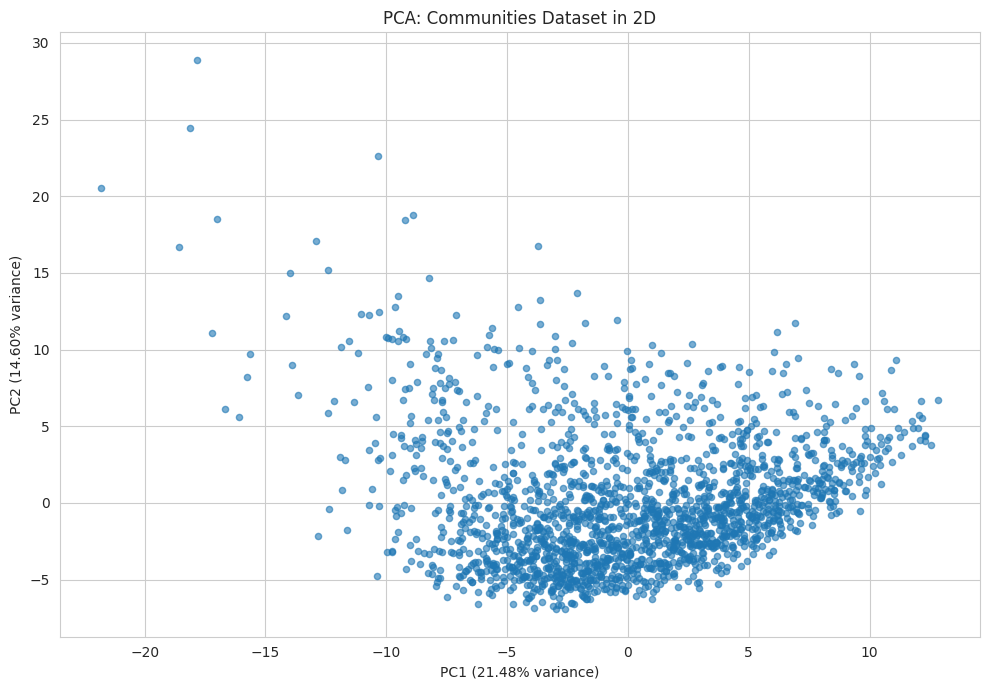

Variance retained by the first two components: 36.09 %


In [14]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    alpha=0.6,
    s=20
)

plt.title("PCA: Communities Dataset in 2D")
plt.xlabel(
    f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.2f}% variance)"
)
plt.ylabel(
    f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.2f}% variance)"
)

plt.grid(True)
plt.tight_layout()
plt.show()

print(
    "Variance retained by the first two components:",
    round(pca_2d.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

In [15]:
comparison = pd.DataFrame({
    "Measurement": [
        "Number of samples",
        "Number of features",
        "Total dimensions"
    ],
    "Original Dataset": [
        X.shape[0],
        X.shape[1],
        X.shape[1]
    ],
    "Reduced Dataset (95% variance)": [
        df_pca.shape[0],
        df_pca.shape[1],
        df_pca.shape[1]
    ]
})

display(comparison)

print(
    f"\nDimensionality reduction: {X.shape[1]} features "
    f"-> {df_pca.shape[1]} principal components"
)

reduction_percentage = (
    (X.shape[1] - df_pca.shape[1]) / X.shape[1]
) * 100

print(f"Reduction in feature count: {reduction_percentage:.2f}%")

,Measurement,Original Dataset,Reduced Dataset (95% variance)
0,Number of samples,1994,1994
1,Number of features,123,45
2,Total dimensions,123,45



Dimensionality reduction: 123 features -> 45 principal components
Reduction in feature count: 63.41%


In [16]:
print("PCA RESULTS AND INTERPRETATION")
print("-" * 40)

print(f"Number of samples: {X.shape[0]}")
print(f"Original numerical features: {X.shape[1]}")
print(f"Selected principal components: {n_components_95}")

print(
    f"Variance retained: "
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
)

print(
    f"Feature-count reduction: {reduction_percentage:.2f}%"
)

print("\nInterpretation:")

print(
    f"1. The dataset originally contained {X.shape[1]} numerical features "
    f"after preprocessing."
)

print(
    f"2. PCA reduced these features to {n_components_95} components "
    f"while retaining at least 95% of the variance."
)

print(
    "3. Standardization ensured that numerical features were placed "
    "on a common scale before PCA."
)

print(
    "4. The explained-variance plots show how much information each "
    "principal component captures and how quickly variance accumulates."
)

print(
    "5. The 2D scatter plot shows the distribution of communities "
    "in the first two principal components. The plot alone does not "
    "establish distinct community clusters."
)

print(
    "6. PCA can reduce computational complexity and feature redundancy, "
    "but the principal components may be harder to interpret than "
    "the original variables."
)

PCA RESULTS AND INTERPRETATION
----------------------------------------
Number of samples: 1994
Original numerical features: 123
Selected principal components: 45
Variance retained: 95.22%
Feature-count reduction: 63.41%

Interpretation:
1. The dataset originally contained 123 numerical features after preprocessing.
2. PCA reduced these features to 45 components while retaining at least 95% of the variance.
3. Standardization ensured that numerical features were placed on a common scale before PCA.
4. The explained-variance plots show how much information each principal component captures and how quickly variance accumulates.
5. The 2D scatter plot shows the distribution of communities in the first two principal components. The plot alone does not establish distinct community clusters.
6. PCA can reduce computational complexity and feature redundancy, but the principal components may be harder to interpret than the original variables.
